# $DMO_{n} + Fatigue_{n-1} \rightarrow Fatigue_{n}$

In [1]:
from src.patient_data_dispatcher import PatientDataDispatcher, PatientDataType
from src.model import DMOLSTM
from src.core.enums import MileStone
from src.core.data_transforms import Transform
from src.train import TrainRegression
from torchmetrics.regression import R2Score

import matplotlib.pyplot as plt

import numpy as np
import torch


In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [3]:
dmo_features = [
    "cadence_30_p90_d",
    "cadence_30_avg_d",
    "ws_30_p90_d",
    "strlen_1030_avg_d",
    "cadence_all_avg_d",
]

In [4]:
pdd = PatientDataDispatcher("config/config.yaml", dmo_features, MileStone.ALL)
ids = list(set(pdd.metadata["Local.Participant"].to_list()))
dmo_data, dmo_labels = pdd.get_patient_data(PatientDataType.MILESTONE, ids=ids)

In [5]:
# remove patients that don't have a full dataset
patient_indexs = []
patient, visit, day, features = dmo_data.shape
for p in range(patient):
    all_visits = True
    for v in range(visit):
        data = dmo_data[p, v]
        label = dmo_labels[p, v]
        if (data == -1.0).any() or label == -1.0:
            all_visits = False

    if all_visits:
        patient_indexs.append(p)

dmo_data = dmo_data[patient_indexs]
dmo_labels = dmo_labels[patient_indexs]

In [6]:
from src.model import lstm_regression
config = lstm_regression
config.notes = "None"

In [7]:
predicted_values = []
actual_values = []

n_patients, n_visit, n_day, n_features = dmo_data.shape
for patient_index in range(n_patients):
    print(f"X Validation {patient_index}")

    # split data
    train_indexes = [i for i in range(n_patients) if i != patient_index]
    train_data = dmo_data[train_indexes].squeeze(dim=0)
    train_label = dmo_labels[train_indexes]

    test_data = dmo_data[patient_index]
    test_label = dmo_labels[patient_index].unsqueeze(dim=0)

    transform = Transform()

    # fit and transform scaler on training data only, then transform testing
    train_data = transform.fit_transform_dmo_data(train_data)
    test_data = transform.transform_dmo_data(test_data)

    # fit and transform scaler on training labels, then transform testing labels
    train_label = transform.fit_transform_dmo_labels(train_label)
    test_label = transform.transform_dmo_labels(test_label)

    # convert to tensors
    train_data = torch.from_numpy(train_data)
    train_label = torch.from_numpy(train_label)

    test_data = torch.from_numpy(test_data)
    test_label = torch.from_numpy(test_label)

    # format data
    train_data = Transform.format_input_data_lag_label(train_data, train_label)
    test_data = Transform.format_input_data_lag_label(test_data, test_label)

    # Convert to dataloaders
    training_dataloader = Transform.data_to_dataloaders(
        train_data, train_label, batch_size=16
    )
    testing_dataloader = Transform.data_to_dataloaders(
        test_data, test_label, batch_size=16
    )

    # reinstantiate model every loop for x validation
    model = DMOLSTM(config).to(device=device)
    optimiser = config.optimiser(model.parameters(), lr=config.learning_rate)

    trainer = TrainRegression(
        model,
        optimiser,
        config,
        training_dataloader,
        testing_dataloader,
        device,
        verbose=True,
    )

    def label_transform(x):
        if len(x.shape) < 3:
            x = x.unsqueeze(dim=0)
        x = x[:, 4, 0]
        return x


    trainer.train_loop(label_transform=label_transform, pred_transform=lambda x: x.squeeze(dim=1))
    prediction, actual = trainer.test_loop(
        label_transform=label_transform
    )

    predicted_values += prediction
    actual_values += actual


X Validation 0
Testing loss: 0.0001607323792995885
X Validation 1
Testing loss: 0.0027975542470812798
X Validation 2
Testing loss: 0.007473573554307222
X Validation 3
Testing loss: 0.0009239086648449302
X Validation 4
Testing loss: 0.02585168369114399
X Validation 5
Testing loss: 0.0006569334072992206
X Validation 6
Testing loss: 0.010015024803578854
X Validation 7
Testing loss: 0.0022300512064248323
X Validation 8
Testing loss: 0.04654252529144287
X Validation 9
Testing loss: 0.00325656495988369
X Validation 10
Testing loss: 7.792383485138998e-07
X Validation 11
Testing loss: 0.005892197135835886
X Validation 12
Testing loss: 0.003925817087292671
X Validation 13
Testing loss: 0.01613771542906761
X Validation 14
Testing loss: 0.002042538020759821
X Validation 15
Testing loss: 0.0006213266169652343
X Validation 16
Testing loss: 0.007127475459128618
X Validation 17
Testing loss: 0.00010087312693940476
X Validation 18
Testing loss: 0.031156981363892555
X Validation 19
Testing loss: 0.0017

All metrics: {'accuracy': 0.627906976744186, 'Mean Squared Error': 0.014097154140472412, 'Mean Absolute Error': 0.09359847754240036, 'R^2': 0.7613803744316101}


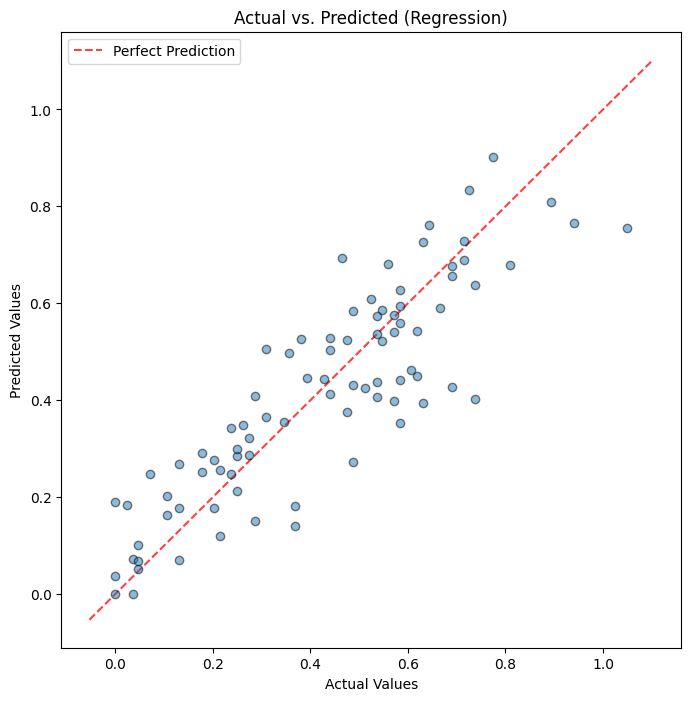

In [8]:
from src.evaluation import Evaluation
import matplotlib.pyplot as plt

actual_values = torch.Tensor(actual_values)
predicted_values = torch.Tensor(predicted_values)

evaluation = Evaluation(predicted_values, actual_values)
print(f"All metrics: {evaluation.compute_all_metrics()}")
evaluation.evaluation_plot().show()
